# ForeverTree LLM panel — headline figures

Headline figures for the H1 comparison (Josh vs Mesa), driven by the
phase6-v2 scorer schema on the post-refactor k8s execution path:

- **Panel A** — substantive pass rate (`substantive_conformance ∧ did_run`)
  by model × target with Wilson 95 % intervals.
- **Panel B** — 5-axis report card (engagement, conformance, execution,
  ecology, contract) per (model, target). Replaces the earlier linear
  cascade — see [analysis/aggregate.py](../analysis/aggregate.py)'s
  `_compute_axes` for the per-axis rules. Each tile renders one dot per
  replicate; failure modes that the cascade collapsed into the same
  level (e.g. "agent never engaged" vs "agent ran but wrote wrong
  CSV schema") are now visually distinct columns.
- **Regression-fit panel** — observed-vs-predicted β, α, R² per cell
  against the spec-faithful reference simulator's acceptance bands.
- **Runtime panel** — `sim_wall_seconds` (pure `./run.sh`) by model ×
  target; the Josh-vs-Mesa runtime comparison from
  [SCORING.md](../SCORING.md).
- **Code / style panel** — `src_loc`, `comment_loc`, `imports_loc`,
  `entropy_bits` per cell.
- **Cost & token panel** — agent-phase OpenRouter spend and tool-call
  activity per cell.
- **Fuzzy judge panel** — Q1 (did the agent actually use the named
  framework?), Q2 (where did it get stuck?), Q3 (does `./run.sh`
  carry the full preprocess + 100×100 contract?), Q4 (Mesa cells:
  does the implementation use `decimal.Decimal` for dynamics?) —
  answered by the in-Pod judge ([prompts/FUZZY_JUDGE.md](../prompts/FUZZY_JUDGE.md)).

Data source: `analysis/aggregated.csv`, produced by `analysis/aggregate.py`,
which walks each batch's cell directories. Cells with no scorer.json (e.g.
agent OOM before scoring) get a synthetic row marked
`engagement_status=no_scorer` so catastrophic non-engagement is visible
in the headline figure rather than silently dropped. Re-aggregate any time
new batches land:

```
pixi run aggregate runs/<batch-tag>
```

All metric definitions come from [SCORING.md](../SCORING.md).


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
# Panel-scope config. Adjust to your batch.
AGGREGATED = Path('aggregated.csv')
# None = include every batch in aggregated.csv. Control which batches
# are included via aggregate.py's --pattern arg or explicit batch dirs
# instead of pinning here — keeps the notebook agnostic to batch-tag names.
BATCH_FILTER = ['panel-9x3-20260529']
# Headline panel as of 2026-05-21 (config/models.yaml). `claude` (opus)
# is available for sensitivity runs but isn't part of the current panel.
MODEL_ORDER  = ['sonnet', 'gemma', 'kimi', 'minimax', 'mistral', 'glm', 'qwen', 'nemotron', 'deepseek']
TARGET_ORDER = ['mesa', 'josh', 'josh-mcp']
TARGET_COLORS = {'josh-mcp': "#43be2b", 'josh': '#2b8cbe', 'mesa': '#e34a33'}
OUT_DIR = Path('figures')
OUT_DIR.mkdir(exist_ok=True)


In [3]:
df = pd.read_csv(AGGREGATED)
if BATCH_FILTER is not None:
    df = df[df['batch_tag'].isin(BATCH_FILTER)].copy()
df = df[df['model'].isin(MODEL_ORDER) & df['target'].isin(TARGET_ORDER)].copy()
print(f'rows: {len(df)}')
print(f'batches: {sorted(df.batch_tag.unique())}')
df.groupby(['model', 'target']).size().unstack(fill_value=0).reindex(index=MODEL_ORDER, columns=TARGET_ORDER)


rows: 27
batches: ['panel-9x3-20260529']


target,mesa,josh,josh-mcp
model,,,
sonnet,1,1,1
gemma,1,1,1
kimi,1,1,1
minimax,1,1,1
mistral,1,1,1
glm,1,1,1
qwen,1,1,1
nemotron,1,1,1
deepseek,1,1,1


In [4]:
def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float, float]:
    """Return (point, low, high) for a binomial proportion. n=0 -> (nan, 0, 1)."""
    if n == 0:
        return float('nan'), 0.0, 1.0
    phat = k / n
    denom = 1 + z*z/n
    centre = (phat + z*z/(2*n)) / denom
    halfwidth = z * math.sqrt(phat*(1-phat)/n + z*z/(4*n*n)) / denom
    return phat, max(0.0, centre - halfwidth), min(1.0, centre + halfwidth)


def cascade_level(row) -> int:
    """[LEGACY] Furthest-gate-reached cascade, kept for paper-writing
    reference. The headline figure now uses the 5-axis heatmap in
    Panel B below — that view makes parallel failure modes (e.g.
    'crashed' vs 'ran but wrong CSV schema') visually distinct,
    which this linear cascade collapses into the same level.
    Mutually exclusive levels 0..4:
       0 = no mechanical conformance (no .josh / no `import mesa`)
       1 = mechanical pass but fuzzy Q1 says no/partial — sidecar fakeout
       2 = substantive conformance, did not run cleanly
       3 = did_run, but regression gate failed
       4 = full pass — did_run AND regression_fit_ok
    """
    if not bool(row.get('target_conformance')):
        return 0
    if not bool(row.get('substantive_conformance')):
        return 1
    if not bool(row.get('did_run')):
        return 2
    if not bool(row.get('regression_fit_ok')):
        return 3
    return 4

df['cascade_level'] = df.apply(cascade_level, axis=1)
df[['model','target','engagement_status','axis_engagement',
    'axis_conformance','axis_execution','axis_ecology','axis_contract']].head()


,model,target,engagement_status,axis_engagement,axis_conformance,axis_execution,axis_ecology,axis_contract
0,deepseek,josh,full_steps_with_files,pass,pass,pass,pass,pass
1,deepseek,josh-mcp,full_steps_with_files,pass,pass,pass,pass,pass
2,deepseek,mesa,full_steps_with_files,pass,pass,pass,pass,pass
3,gemma,josh,no_scorer,fail,fail,na,na,fail
4,gemma,josh-mcp,no_scorer,fail,fail,na,na,fail


## Panel A — H1: substantive pass rate by model × target

H1 (EXPERIMENTAL_DESIGN.md): _a higher fraction of Josh implementations will run
and pass validation than Mesa implementations_. Bars show the per-(model, target)
mean of **`substantive_conformance AND did_run`** — the agent must have actually
used the named framework (per the fuzzy Q1 verdict, not just the mechanical grep)
*and* produced a clean run. Error bars are Wilson 95 % intervals. Labels above
bars show `k/N`.

Cells that are fake-outs (mechanical-only conformance with a Python sidecar
doing the real work) get filtered out here; they show up in Panel B's level-1
bucket instead.


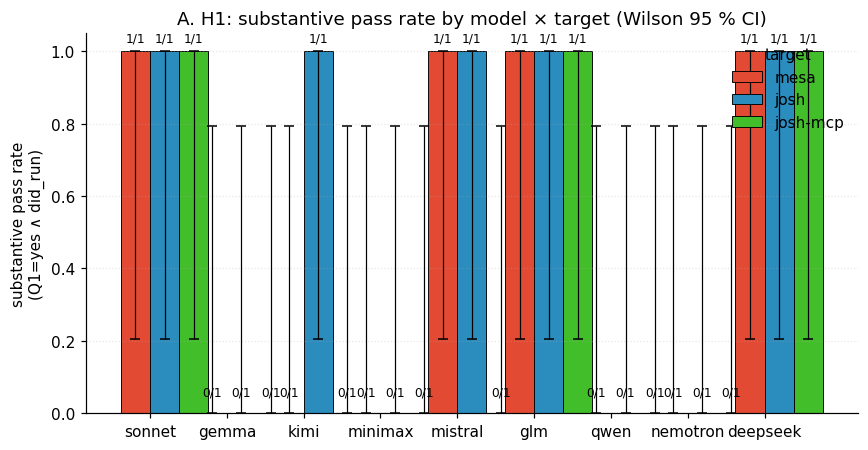

In [5]:
def panel_a(df_in: pd.DataFrame, ax: plt.Axes) -> None:
    """H1 pass-rate panel — bars (substantive_conformance ∧ did_run).

    The pass criterion combines two gates: the fuzzy judge's Q1 verdict
    (substantive use of the named framework, not just a parseable shell)
    and the mechanical did_run (script exited 0 + CSV schema OK). Either
    failure mode drops the cell from the numerator.
    """
    width = 0.38
    x = np.arange(len(MODEL_ORDER))
    pass_mask = df_in['substantive_conformance'].astype(bool) & df_in['did_run'].astype(bool)
    df_in = df_in.assign(_substantive_pass=pass_mask)
    for i, tgt in enumerate(TARGET_ORDER):
        means, lows, highs, labels = [], [], [], []
        for m in MODEL_ORDER:
            sub = df_in[(df_in.model == m) & (df_in.target == tgt)]
            k = int(sub['_substantive_pass'].sum()) if not sub.empty else 0
            n = len(sub)
            phat, lo, hi = wilson_ci(k, n)
            means.append(phat if not math.isnan(phat) else 0)
            lows.append(0 if math.isnan(phat) else phat - lo)
            highs.append(0 if math.isnan(phat) else hi - phat)
            labels.append(f'{k}/{n}' if n else '0/0')
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, means, width, label=tgt, color=TARGET_COLORS[tgt],
                      edgecolor='black', linewidth=0.6)
        ax.errorbar(x + offset, means, yerr=[lows, highs], fmt='none',
                    color='black', capsize=3, linewidth=0.8)
        for xi, lbl, m in zip(x + offset, labels, means):
            ax.text(xi, max(m + 0.02, 0.04), lbl, ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylabel('substantive pass rate\n(Q1=yes ∧ did_run)')
    ax.set_ylim(0, 1.05)
    ax.set_title('A. H1: substantive pass rate by model × target (Wilson 95 % CI)')
    ax.legend(title='target', loc='upper right', frameon=False)
    ax.grid(axis='y', alpha=0.3, linestyle=':')


fig, ax = plt.subplots(figsize=(8, 4.2))
panel_a(df, ax)
fig.tight_layout()
plt.show()


## Panel B — 5-axis report card: where do cells get stuck?

Each (model, target) cell-group renders as five small tiles, one per axis:

| Axis | 🟢 pass | 🟡 caveat | 🔴 fail | ⚪ n/a |
|---|---|---|---|---|
| **engagement** | 8 steps + ≥1 file written | partial steps OR no files | no `scorer.json` (catastrophic) | — |
| **conformance** | mech ✓ AND Q1=yes | mech ✓ AND Q1=partial | mech ✗ OR Q1=no | mech ✓ AND parse_error |
| **execution** | exit 0 AND CSV exists | timed_out | exit≠0 OR no CSV | engagement 🔴 |
| **ecology** | `regression_fit_ok` | `height_in_range` only | both fail | execution not 🟢 |
| **contract** | csv_schema_ok ✓ AND Q3=yes AND Q4∈{yes,n-a} | csv_schema_ok ✓ AND (Q3=partial OR Q4=partial) | csv_schema_ok ✗ OR Q3=no OR Q4=no | parse_error |

Within each tile, one dot per replicate (with-jitter when N>1). The axes are
deliberately not collapsed into a single cascade — a `did_run=True,
regression_fit_ok=True` cell with `csv_schema_ok=False` (kimi-mesa
pattern: `patch_id` instead of `cell_id`) lands at execution 🟢 + contract 🔴,
visually distinguishable from a crashed run at execution 🔴 + contract 🔴.
Likewise, the 10 cells in `panel-9x3-20260529` that produced no
`scorer.json` at all (gemma×3, qwen×3, nemotron×3, kimi-josh-mcp) show
up as engagement 🔴 — under the previous cascade they were silently
dropped from the figure entirely.

All axis values are pre-computed in `analysis/aggregate.py` so a
re-aggregation against the same batch is the rescore path. See
[SCORING.md](../SCORING.md) for the underlying metric definitions and
[TWEAKS.md](../TWEAKS.md) for the rationale behind each axis cutoff.


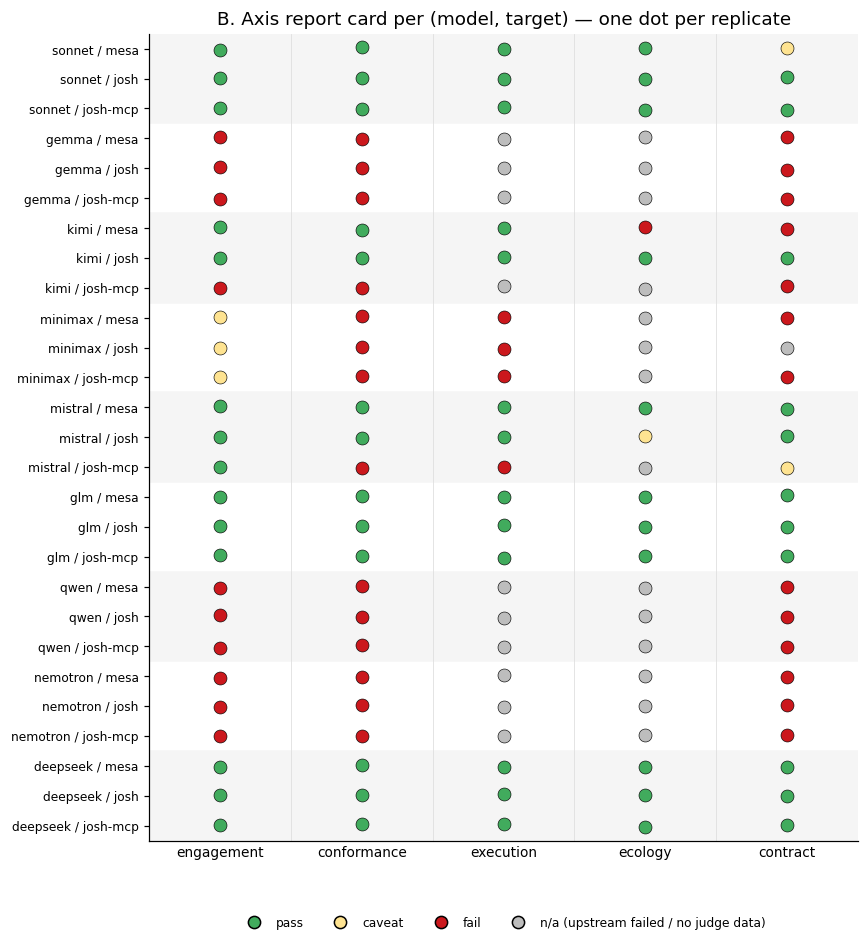

In [6]:
# 5-axis report-card heatmap. The axes are produced by aggregate.py
# (`axis_engagement`, `axis_conformance`, `axis_execution`, `axis_ecology`,
# `axis_contract`); the notebook just lays them out. Each tile renders
# one dot per replicate (with small jitter when N>1) coloured by axis
# status — pass / caveat / fail / na.
AXES = [
    ('axis_engagement',  'engagement'),
    ('axis_conformance', 'conformance'),
    ('axis_execution',   'execution'),
    ('axis_ecology',     'ecology'),
    ('axis_contract',    'contract'),
]
AXIS_STATUS_COLORS = {
    'pass':   '#41ab5d',  # green
    'caveat': '#fee391',  # yellow
    'fail':   '#cb181d',  # red
    'na':     '#bdbdbd',  # grey — axis not applicable given upstream failure
}


def panel_b(df_in: pd.DataFrame, ax: plt.Axes) -> None:
    """5-axis report-card heatmap per (model, target).

    Rows are (model, target) pairs in MODEL_ORDER × TARGET_ORDER order
    (mesa, josh, josh-mcp per row group). Columns are the five axes.
    Within each tile, replicates render as small dots laid out
    horizontally so dispersion across the N runs is preserved without
    averaging status colors. Empty (no rows at all for a (model,
    target) pair) tiles are drawn as a faint ⚪ box.
    """
    rows = [(m, t) for m in MODEL_ORDER for t in TARGET_ORDER]
    n_rows = len(rows)
    n_axes = len(AXES)
    rng = np.random.default_rng(seed=17)

    # Background — alternating row shading so the eye groups by model.
    for i, (m, _t) in enumerate(rows):
        if MODEL_ORDER.index(m) % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color='#f5f5f5', zorder=0)

    for row_idx, (m, t) in enumerate(rows):
        sub = df_in[(df_in.model == m) & (df_in.target == t)]
        if sub.empty:
            # No row at all (e.g. model not run for this target). Render
            # the whole row as a faint reminder rather than leaving it blank.
            for col_idx in range(n_axes):
                ax.text(col_idx, row_idx, '—', ha='center', va='center',
                        fontsize=8, color='#bdbdbd', zorder=2)
            continue
        n = len(sub)
        for col_idx, (field, _label) in enumerate(AXES):
            statuses = sub[field].fillna('na').tolist()
            # Lay N dots in a horizontal strip centred on the tile x.
            half = 0.32
            if n == 1:
                xs = [col_idx]
            else:
                xs = np.linspace(col_idx - half, col_idx + half, n)
            # Tiny y-jitter so overlapping dots from the same axis are
            # readable when N>1.
            ys = row_idx + rng.uniform(-0.06, 0.06, size=n)
            colors = [AXIS_STATUS_COLORS.get(s, AXIS_STATUS_COLORS['na'])
                      for s in statuses]
            ax.scatter(xs, ys, c=colors, s=72 if n == 1 else 48,
                       edgecolor='black', linewidth=0.4, zorder=3)

    ax.set_xticks(range(n_axes))
    ax.set_xticklabels([label for _, label in AXES], fontsize=9)
    ax.tick_params(axis='x', which='both', length=0)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([f'{m} / {t}' for (m, t) in rows], fontsize=8)
    ax.set_xlim(-0.5, n_axes - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)  # invert so first row is on top
    ax.set_title('B. Axis report card per (model, target) — one dot per replicate')

    # Vertical separators between axes for legibility.
    for x in np.arange(0.5, n_axes - 0.5):
        ax.axvline(x, color='#dddddd', linewidth=0.5, zorder=1)

    # Legend below the plot so it doesn't crowd the tiles.
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=AXIS_STATUS_COLORS['pass'],
               markeredgecolor='black', markersize=8, label='pass'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=AXIS_STATUS_COLORS['caveat'],
               markeredgecolor='black', markersize=8, label='caveat'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=AXIS_STATUS_COLORS['fail'],
               markeredgecolor='black', markersize=8, label='fail'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=AXIS_STATUS_COLORS['na'],
               markeredgecolor='black', markersize=8, label='n/a (upstream failed / no judge data)'),
    ]
    ax.legend(handles=handles, loc='upper center',
              bbox_to_anchor=(0.5, -0.08), ncols=4, frameon=False, fontsize=8)


fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(MODEL_ORDER) * len(TARGET_ORDER))))
panel_b(df, ax)
fig.tight_layout()
plt.show()


## Combined headline figure (Panels A + B)

Stack the H1 pass-rate panel and the gate-cascade panel into one figure
for the paper and save to `figures/headline.{pdf,png}`. Regression-fit
detail and runtime live in their own figures below.


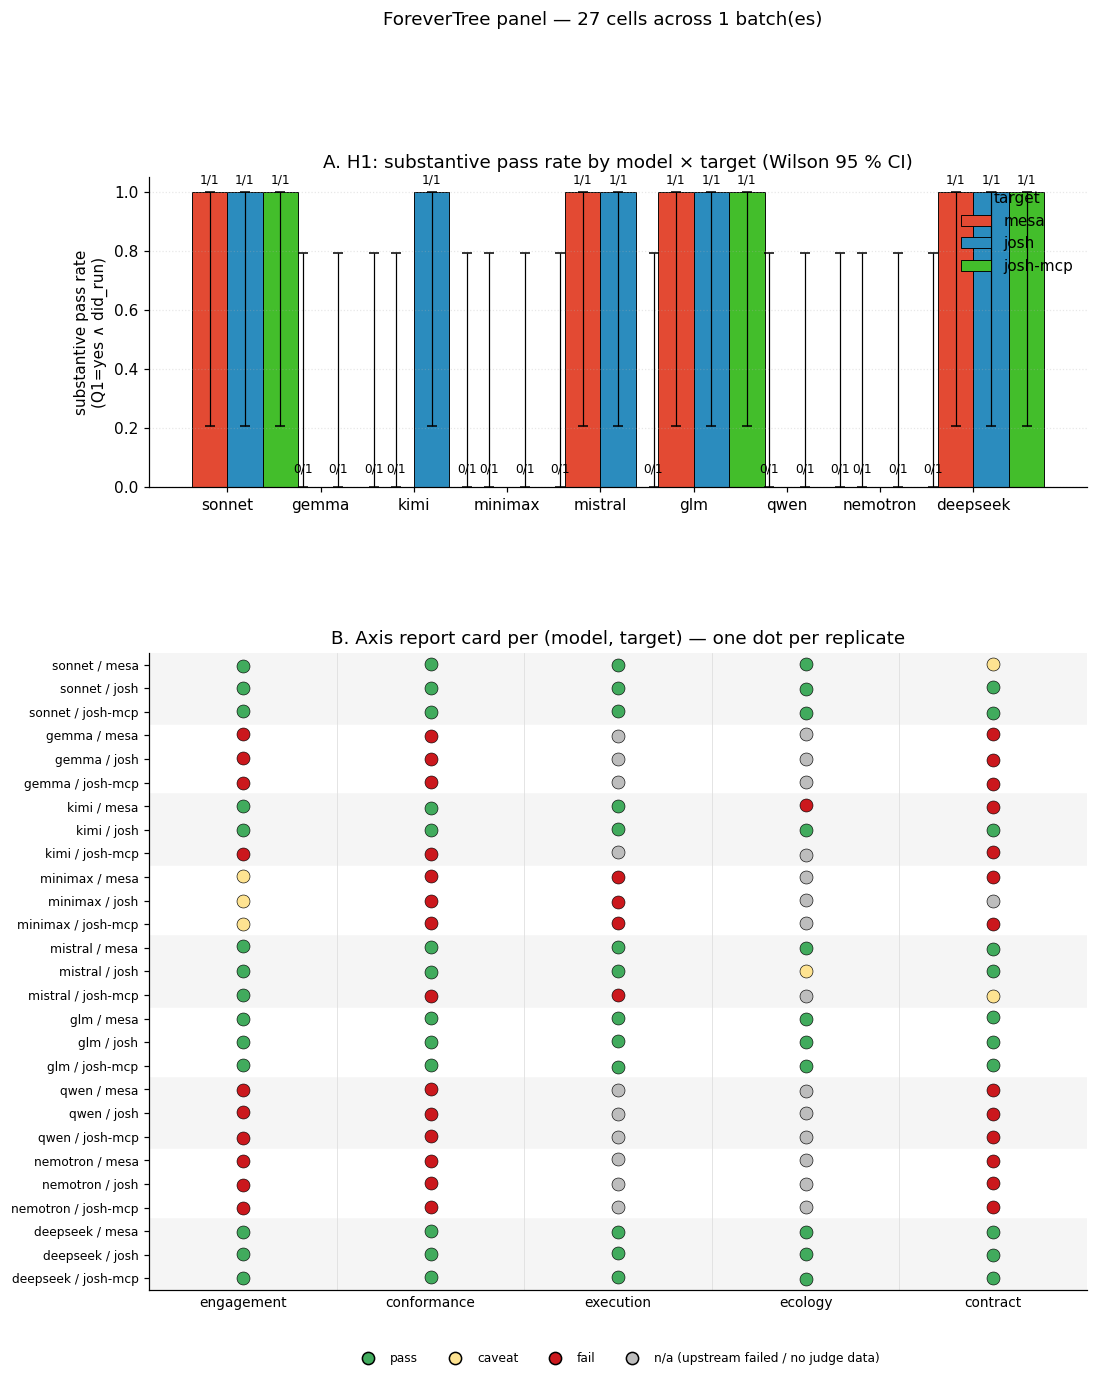

Wrote figures/headline.pdf and figures/headline.png


In [7]:
# Combined headline figure — Panel A bars on top, Panel B axis heatmap below.
# Panel B's height scales with len(MODEL_ORDER × TARGET_ORDER) so the
# rows stay legible regardless of panel size.
panel_b_height = max(4, 0.32 * len(MODEL_ORDER) * len(TARGET_ORDER))
fig = plt.figure(figsize=(11, 4.5 + panel_b_height))
gs = fig.add_gridspec(2, 1, height_ratios=[4.2, panel_b_height], hspace=0.35)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
panel_a(df, ax_a)
panel_b(df, ax_b)
fig.suptitle(
    f'ForeverTree panel — {len(df)} cells across '
    f'{df.batch_tag.nunique()} batch(es)',
    fontsize=12, y=0.995,
)
fig.savefig(OUT_DIR / 'headline.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'headline.png', bbox_inches='tight')
plt.show()
print(f'Wrote {OUT_DIR / "headline.pdf"} and {OUT_DIR / "headline.png"}')


## Regression-fit panel — observed vs predicted, per cell

The phase-6 ecology gate is an `observed ~ predicted` regression of
year-100 mean height per (cell, replicate) against the spec-faithful
reference simulator's deterministic prediction (see
[harness/spec_model.py](../harness/spec_model.py) and
[data/reference_sim.py](../data/reference_sim.py)).

Three subplots show β, α, R² per cell with the acceptance band overlaid:

- **β ∈ [0.95, 1.05]** — slope ≈ 1 if observed growth tracks predicted.
- **α ∈ [−0.5, 0.5] m** — intercept near 0 if there's no offset bias.
- **R² ≥ 0.95** — variance captured by the deterministic prediction.

A spec-faithful run lands inside all three bands. The fourth subplot
shows the year-100 mean height as a coarse secondary sanity check
(acceptance band from `height_year100` in acceptance_ranges.json).

Only cells with `did_run = True` are shown — the metrics are undefined
for crashed runs.


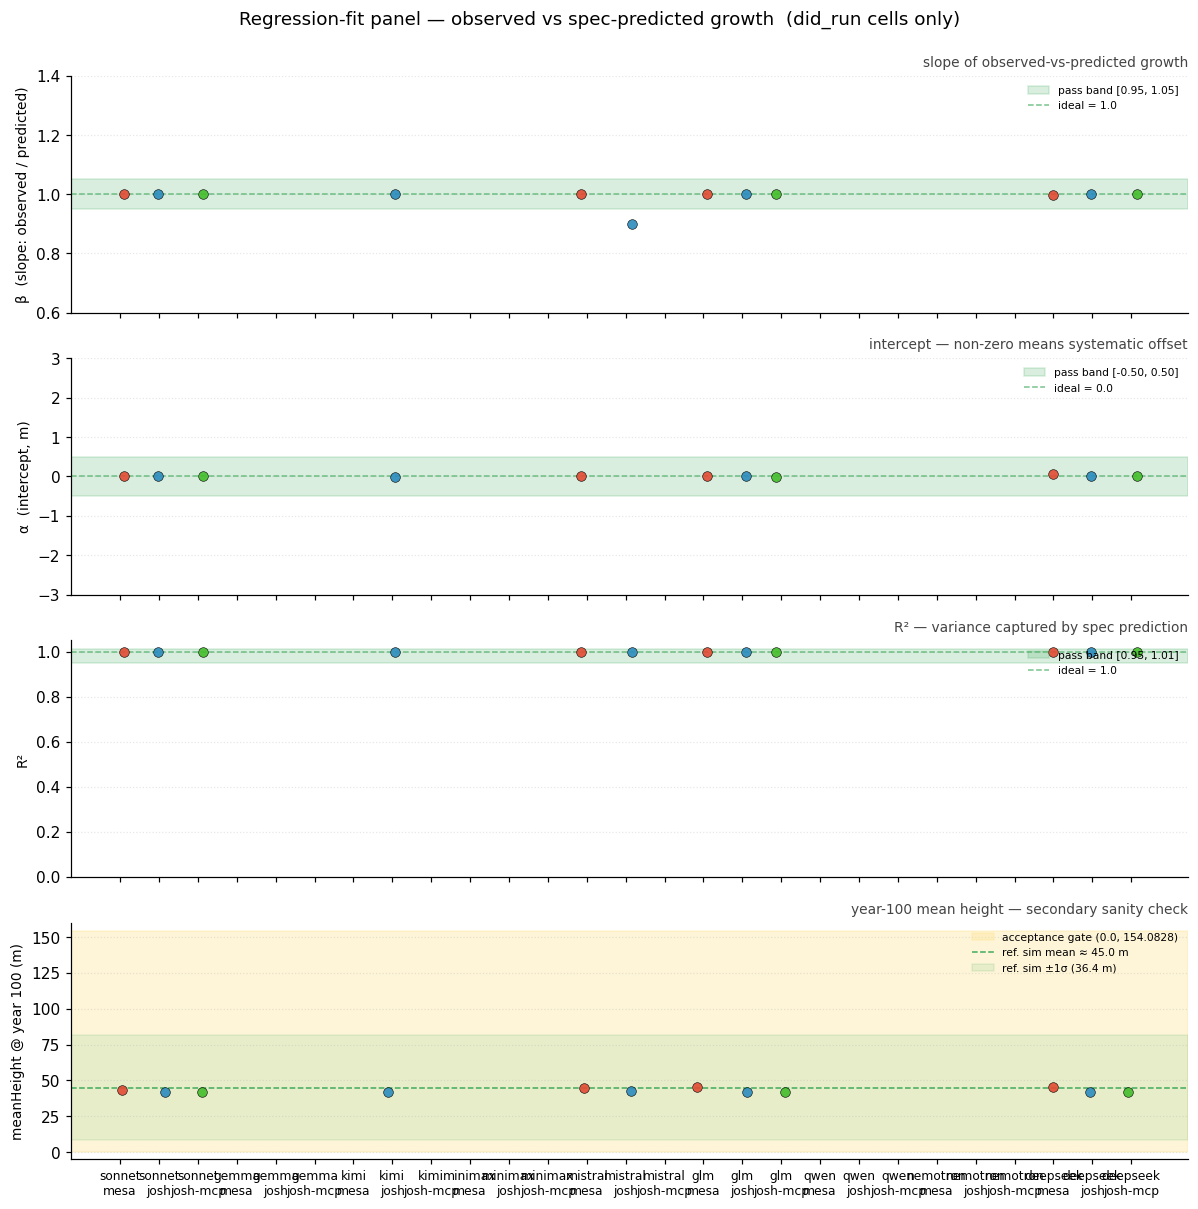

Wrote figures/regression.pdf and figures/regression.png


In [8]:
# Acceptance band targets — copied from harness/acceptance_ranges.json.
# Hard-coded so the notebook runs without re-reading the harness fixture;
# update both if the bands move.
REGRESSION_BANDS = {
    'beta':  {'lo': 0.95, 'hi': 1.05, 'ideal': 1.0,
              'ylabel': 'β  (slope: observed / predicted)',
              'ylim': (0.6, 1.4)},
    'alpha': {'lo': -0.5, 'hi': 0.5, 'ideal': 0.0,
              'ylabel': 'α  (intercept, m)',
              'ylim': (-3.0, 3.0)},
    'r2':    {'lo': 0.95, 'hi': 1.01, 'ideal': 1.0,
              'ylabel': 'R²',
              'ylim': (0.0, 1.05)},
}

# Year-100 mean height secondary sanity band, from acceptance_ranges.json:
HEIGHT_Y100_BAND = (0.0, 154.0828)
HEIGHT_Y100_OBSERVED_MEAN = 45.0101   # reference simulator
HEIGHT_Y100_OBSERVED_STD  = 36.3576


def _scatter_one(ax, df_in, field, band, title=None):
    df_eco = df_in[df_in['did_run'] == True].copy()  # noqa: E712 pandas bool
    df_eco['xkey'] = df_eco['model'] + '\n' + df_eco['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=42)

    # Acceptance band as a pale yellow rectangle; ideal value as dashed line.
    ax.axhspan(band['lo'], band['hi'], color='#41ab5d', alpha=0.20,
               label=f'pass band [{band["lo"]:.2f}, {band["hi"]:.2f}]')
    ax.axhline(band['ideal'], color='#41ab5d', linewidth=1.0,
               linestyle='--', alpha=0.7, label=f'ideal = {band["ideal"]}')

    for g in groups:
        sub = df_eco[df_eco['xkey'] == g]
        if sub.empty:
            continue
        xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
        ys = sub[field].astype(float)
        cs = [TARGET_COLORS[t] for t in sub['target']]
        ax.scatter(xs, ys, c=cs, s=40, alpha=0.9, edgecolor='black',
                   linewidth=0.4, zorder=3)

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, fontsize=7)
    ax.set_ylabel(band['ylabel'], fontsize=9)
    ax.set_ylim(*band['ylim'])
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.legend(loc='upper right', fontsize=7, frameon=False)
    if title:
        ax.set_title(title, fontsize=9, loc='right', color='#444')


def panel_regression(df_in, axes):
    _scatter_one(axes[0], df_in, 'regression_beta',  REGRESSION_BANDS['beta'],
                 title='slope of observed-vs-predicted growth')
    _scatter_one(axes[1], df_in, 'regression_alpha', REGRESSION_BANDS['alpha'],
                 title='intercept — non-zero means systematic offset')
    _scatter_one(axes[2], df_in, 'regression_r2',    REGRESSION_BANDS['r2'],
                 title='R² — variance captured by spec prediction')
    # Year-100 mean height sanity panel.
    h_ax = axes[3]
    h_ax.axhspan(*HEIGHT_Y100_BAND, color='#fee391', alpha=0.35,
                 label=f'acceptance gate {HEIGHT_Y100_BAND}')
    h_ax.axhline(HEIGHT_Y100_OBSERVED_MEAN, color='#41ab5d',
                 linewidth=1.0, linestyle='--',
                 label=f'ref. sim mean ≈ {HEIGHT_Y100_OBSERVED_MEAN:.1f} m')
    h_ax.axhspan(HEIGHT_Y100_OBSERVED_MEAN - HEIGHT_Y100_OBSERVED_STD,
                 HEIGHT_Y100_OBSERVED_MEAN + HEIGHT_Y100_OBSERVED_STD,
                 color='#41ab5d', alpha=0.12,
                 label=f'ref. sim ±1σ ({HEIGHT_Y100_OBSERVED_STD:.1f} m)')
    df_eco = df_in[df_in['did_run'] == True].copy()
    df_eco['xkey'] = df_eco['model'] + '\n' + df_eco['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=7)
    for g in groups:
        sub = df_eco[df_eco['xkey'] == g]
        if sub.empty:
            continue
        xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
        cs = [TARGET_COLORS[t] for t in sub['target']]
        h_ax.scatter(xs, sub['height_year100_mean'].astype(float),
                     c=cs, s=40, alpha=0.9, edgecolor='black',
                     linewidth=0.4, zorder=3)
    h_ax.set_xticks(range(len(groups)))
    h_ax.set_xticklabels(groups, fontsize=7)
    h_ax.set_ylabel('meanHeight @ year 100 (m)', fontsize=9)
    h_ax.set_ylim(-5, 160)
    h_ax.grid(axis='y', alpha=0.3, linestyle=':')
    h_ax.legend(loc='upper right', fontsize=7, frameon=False)
    h_ax.set_title('year-100 mean height — secondary sanity check',
                   fontsize=9, loc='right', color='#444')


fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)
panel_regression(df, axes)
axes[-1].tick_params(axis='x', labelsize=8)
fig.suptitle('Regression-fit panel — observed vs spec-predicted growth  (did_run cells only)',
             y=0.995, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'regression.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'regression.png', bbox_inches='tight')
plt.show()
print(f'Wrote {OUT_DIR / "regression.pdf"} and {OUT_DIR / "regression.png"}')


## Sim-runtime panel — `sim_wall_seconds` per cell

`sim_wall_seconds` is the time spent inside `./run.sh` only — the scorer
container runs with `--network=none` and no LLM. This is the right
metric for the Josh-vs-Mesa runtime comparison the paper makes; agent /
LLM wall time lives in the cost panel below.

KUBE_WATCH §9 noted "mesa: 5–10 min, josh: 30–60 min" from kubectl wall
clock; this panel shows the scorer-truth version of that observation.
The y-axis is log-scaled because Josh's 100-replicate × 100-year sim is
two orders of magnitude slower than Mesa's at this resolution.

Marker shape encodes `did_run` (filled circle = ran clean, open triangle
= failed — for failed cells, `sim_wall_seconds` reflects whatever
fragment of `./run.sh` got executed before crashing).


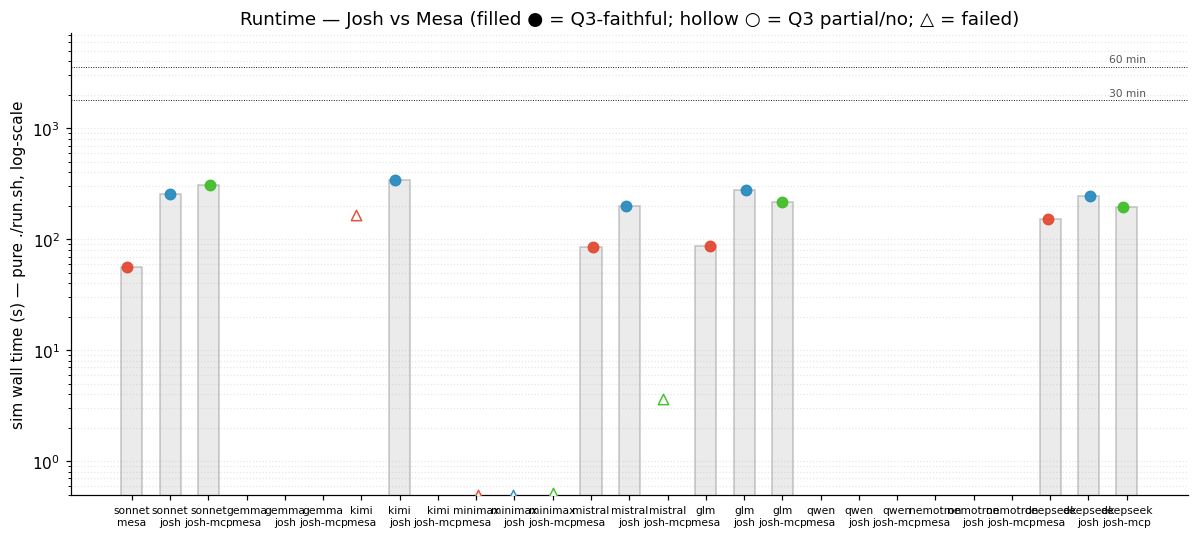

Wrote figures/runtime.pdf and figures/runtime.png


In [9]:
# Q3 marker semantics — fuzzy_q3_answer pulls from scorer.fuzzy.json
# (written by run-judge.sh in the scorer container, or the host-side
# orchestration/run_fuzzy_judge.sh on a pulled batch). Three states:
#   - did_run = False               → open triangle (cell failed)
#   - did_run, q3 ∈ {'partial','no'} → hollow circle (ran, but ./run.sh
#                                       missed preprocess / 100-reps /
#                                       100-years → NOT apples-to-apples)
#   - did_run, q3 = 'yes' or NaN    → filled circle (apples-to-apples
#                                       under the Q3 contract)
def _runtime_marker_style(ran, q3_answer, target):
    if not bool(ran):
        return {"marker": "^", "facecolor": "white",
                "edgecolor": TARGET_COLORS[target], "linewidth": 1.0}
    if q3_answer in ("partial", "no"):
        return {"marker": "o", "facecolor": "white",
                "edgecolor": TARGET_COLORS[target], "linewidth": 1.5}
    return {"marker": "o", "facecolor": TARGET_COLORS[target],
            "edgecolor": TARGET_COLORS[target], "linewidth": 1.0}


def panel_runtime(df_in: pd.DataFrame, ax: plt.Axes) -> None:
    df_r = df_in.copy()
    df_r['xkey'] = df_r['model'] + '\n' + df_r['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=11)

    # Backdrop bar = median over did_run cells.
    for g in groups:
        sub = df_r[(df_r['xkey'] == g) & (df_r['did_run'] == True)]  # noqa: E712
        if sub.empty:
            continue
        med = float(sub['sim_wall_seconds'].median())
        ax.bar(x_index[g], med, width=0.55, color='lightgrey',
               edgecolor='grey', alpha=0.45, zorder=1)

    for g in groups:
        sub = df_r[df_r['xkey'] == g]
        if sub.empty:
            continue
        xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
        for x, val, ran, tgt, q3 in zip(xs,
                                          sub['sim_wall_seconds'].astype(float),
                                          sub['did_run'],
                                          sub['target'],
                                          sub.get('fuzzy_q3_answer', pd.Series([None]*len(sub)))):
            style = _runtime_marker_style(ran, q3, tgt)
            y_plot = max(float(val), 0.5)
            ax.scatter([x], [y_plot], s=46, alpha=0.95, zorder=3,
                       marker=style["marker"], c=[style["facecolor"]],
                       edgecolor=style["edgecolor"], linewidth=style["linewidth"])

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, fontsize=7)
    ax.set_yscale('log')
    ax.set_ylim(0.5, 7200)
    ax.set_ylabel('sim wall time (s) — pure ./run.sh, log-scale')
    ax.grid(axis='y', alpha=0.3, linestyle=':', which='both')
    ax.set_title('Runtime — Josh vs Mesa (filled ● = Q3-faithful; hollow ○ = Q3 partial/no; △ = failed)')

    for sec, lbl in ((1800, '30 min'), (3600, '60 min')):
        ax.axhline(sec, color='black', linewidth=0.6, linestyle=':')
        ax.text(len(groups) - 0.5, sec * 1.05, lbl, fontsize=7, va='bottom',
                ha='right', color='#555')


fig, ax = plt.subplots(figsize=(11, 5))
panel_runtime(df, ax)
fig.tight_layout()
fig.savefig(OUT_DIR / 'runtime.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'runtime.png', bbox_inches='tight')
plt.show()
print(f'Wrote {OUT_DIR / "runtime.pdf"} and {OUT_DIR / "runtime.png"}')


## Code / style panel — LOC, imports, comments, token entropy

EXPERIMENTAL_DESIGN.md predicts that Josh implementations should be *more
concise* than Mesa ones — the DSL has fewer free decisions, fewer scaffolding
files, and a more direct spec-to-executable mapping. Four metrics from
SCORING.md make this visible per cell:

- **`src_loc`** — lines of generated source. `.jshd` binary preprocessed
  data is excluded ([harness/_files.py](../harness/_files.py)).
- **`comment_loc`** — lines that are pure comments. The master prompt
  asks for "self-documenting, wherever possible, with comments minimized"
  (BASE_PROMPT.md §Style), so this also doubles as a prompt-adherence
  signal.
- **`imports_loc`** — `import` statements only. Mesa needs a much wider
  imports surface than Josh (a `.josh` file declares its modules
  natively).
- **`entropy_bits`** — token-level Shannon entropy of the generated code
  via tiktoken's `cl100k_base`. Higher = more varied vocabulary; very low
  values often indicate boilerplate-heavy or near-empty files.

Marker shape encodes `did_run` (filled circle = ran cleanly; open
triangle = failed). A cell at `src_loc=0` with an open triangle is
"agent never engaged at all".


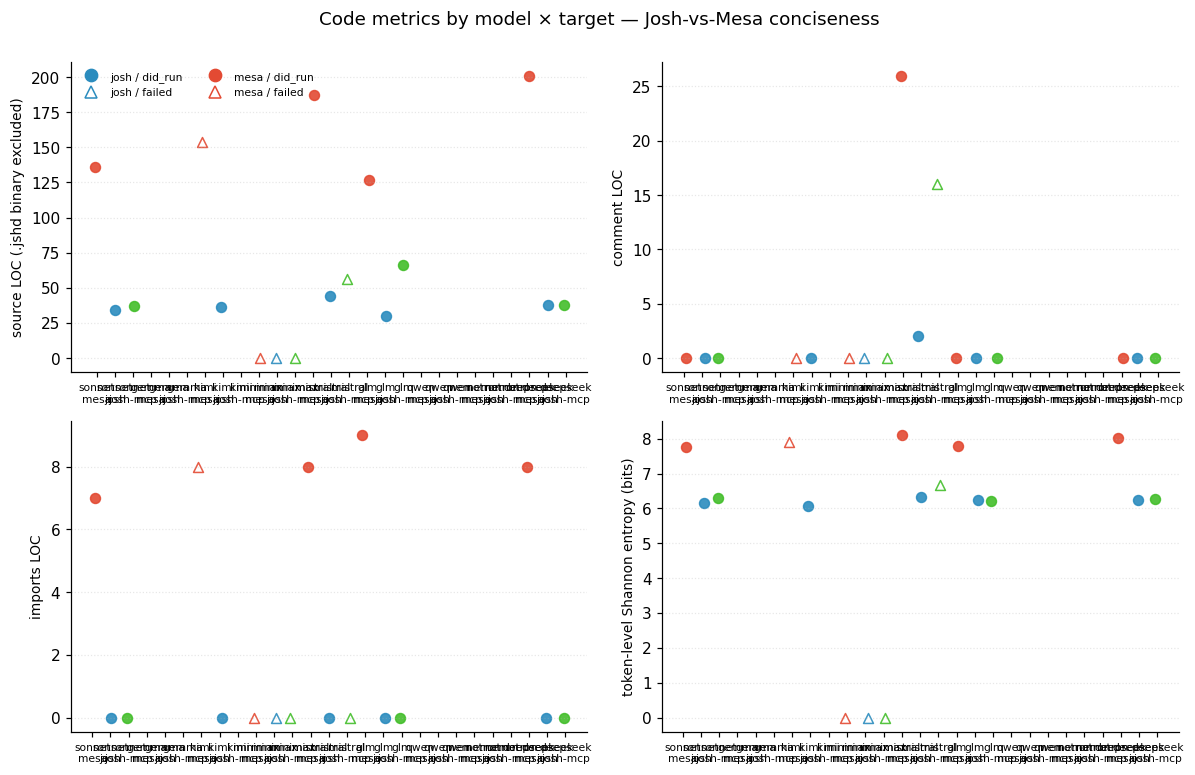

n  src_loc_median  src_loc_max  comment_loc_median  \
model    target                                                         
sonnet   mesa      1           136.0        136.0                 0.0   
         josh      1            34.0         34.0                 0.0   
         josh-mcp  1            37.0         37.0                 0.0   
gemma    mesa      1             NaN          NaN                 NaN   
         josh      1             NaN          NaN                 NaN   
         josh-mcp  1             NaN          NaN                 NaN   
kimi     mesa      1           154.0        154.0                 0.0   
         josh      1            36.0         36.0                 0.0   
         josh-mcp  1             NaN          NaN                 NaN   
minimax  mesa      1             0.0          0.0                 0.0   
         josh      1             0.0          0.0                 0.0   
         josh-mcp  1             0.0          0.0                 0.0   
mistral  mesa      1           187.0        187.0                26.0   
         josh      1            44.0         44.0                 2.0   
         josh-mcp  1            56.0         56.0                16.0   
glm      mesa      1           127.0        127.0                 0.0   
         josh      1            30.0         30.0                 0.0   
         josh-mcp  1            66.0         66.0                 0.0   
qwen     mesa      1             NaN          NaN                 NaN   
         josh      1             NaN          NaN                 NaN   
         josh-mcp  1             NaN          NaN                 NaN   
nemotron mesa      1             NaN          NaN                 NaN   
         josh      1             NaN          NaN                 NaN   
         josh-mcp  1             NaN          NaN                 NaN   
deepseek mesa      1           201.0        201.0                 0.0   
         josh      1            38.0         38.0                 0.0   
         josh-mcp  1            38.0         38.0                 0.0   

                   imports_loc_median  entropy_bits_median  
model    target                                             
sonnet   mesa                     7.0                 7.77  
         josh                     0.0                 6.15  
         josh-mcp                 0.0                 6.30  
gemma    mesa                     NaN                  NaN  
         josh                     NaN                  NaN  
         josh-mcp                 NaN                  NaN  
kimi     mesa                     8.0                 7.90  
         josh                     0.0                 6.06  
         josh-mcp                 NaN                  NaN  
minimax  mesa                     0.0                 0.00  
         josh                     0.0                 0.00  
         josh-mcp                 0.0                 0.00  
mistral  mesa                     8.0                 8.10  
         josh                     0.0                 6.34  
         josh-mcp                 0.0                 6.67  
glm      mesa                     9.0                 7.78  
         josh                     0.0                 6.23  
         josh-mcp                 0.0                 6.22  
qwen     mesa                     NaN                  NaN  
         josh                     NaN                  NaN  
         josh-mcp                 NaN                  NaN  
nemotron mesa                     NaN                  NaN  
         josh                     NaN                  NaN  
         josh-mcp                 NaN                  NaN  
deepseek mesa                     8.0                 8.01  
         josh                     0.0                 6.25  
         josh-mcp                 0.0                 6.26

In [10]:
CODE_FIELDS = [
    ('src_loc',      'source LOC (.jshd binary excluded)', None),
    ('comment_loc',  'comment LOC',                         None),
    ('imports_loc',  'imports LOC',                         None),
    ('entropy_bits', 'token-level Shannon entropy (bits)',  None),
]


def panel_code(df_in: pd.DataFrame, axes: np.ndarray) -> None:
    df_code = df_in.copy()
    df_code['xkey'] = df_code['model'] + '\n' + df_code['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=11)

    for ax, (field, ylabel, _) in zip(axes.flat, CODE_FIELDS):
        for g in groups:
            sub = df_code[df_code['xkey'] == g]
            if sub.empty:
                continue
            xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
            for x, val, ran, tgt in zip(xs, sub[field].astype(float),
                                         sub['did_run'], sub['target']):
                marker = 'o' if bool(ran) else '^'
                facecolor = TARGET_COLORS[tgt] if bool(ran) else 'white'
                ax.scatter([x], [val], marker=marker, c=[facecolor],
                           s=42, alpha=0.9,
                           edgecolor=TARGET_COLORS[tgt], linewidth=1.0)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(groups, fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle=':')

    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=TARGET_COLORS['josh'],
               markeredgecolor=TARGET_COLORS['josh'], markersize=8,
               label='josh / did_run'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='white',
               markeredgecolor=TARGET_COLORS['josh'], markersize=8,
               label='josh / failed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=TARGET_COLORS['mesa'],
               markeredgecolor=TARGET_COLORS['mesa'], markersize=8,
               label='mesa / did_run'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='white',
               markeredgecolor=TARGET_COLORS['mesa'], markersize=8,
               label='mesa / failed'),
    ]
    axes.flat[0].legend(handles=legend_handles, loc='upper left',
                        fontsize=7, frameon=False, ncols=2)


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panel_code(df, axes)
fig.suptitle('Code metrics by model × target — Josh-vs-Mesa conciseness',
             y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'code.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'code.png', bbox_inches='tight')
plt.show()

# Companion table — medians + N so the figure has a number to point at.
loc_tbl = (df.groupby(['model', 'target'])
             .agg(n=('src_loc', 'size'),
                  src_loc_median=('src_loc', 'median'),
                  src_loc_max=('src_loc', 'max'),
                  comment_loc_median=('comment_loc', 'median'),
                  imports_loc_median=('imports_loc', 'median'),
                  entropy_bits_median=('entropy_bits', 'median'))
             .reindex(index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                                       names=['model', 'target']),
                      fill_value=0))
loc_tbl.round(2)


## Agent cost & activity — full agent-phase spend

The agent-phase OpenRouter spend and tool-call activity per cell, summed
across all 8 per-step session exports under
`agent_meta/steps/step_NN/session_export.json`. The cell-level
`agent_meta/session_export.json` is final-step-only and under-counts
whole-cell totals by ~6×; the aggregator does the per-step rollup.

| Column | What it measures |
|---|---|
| `agent_wall_seconds` | first step's `started_at` → last step's `ended_at` across all 8 opencode invocations |
| `agent_cost_usd` | sum of `info.cost` across the 8 per-step exports |
| `agent_tool_calls` | sum of `parts[type=tool]` counts across all 8 step exports |

Marker shape encodes `did_run` (filled = ran cleanly; open triangle =
failed). The sim-runtime panel above isolates `./run.sh` time; this
panel is about LLM-driven activity.


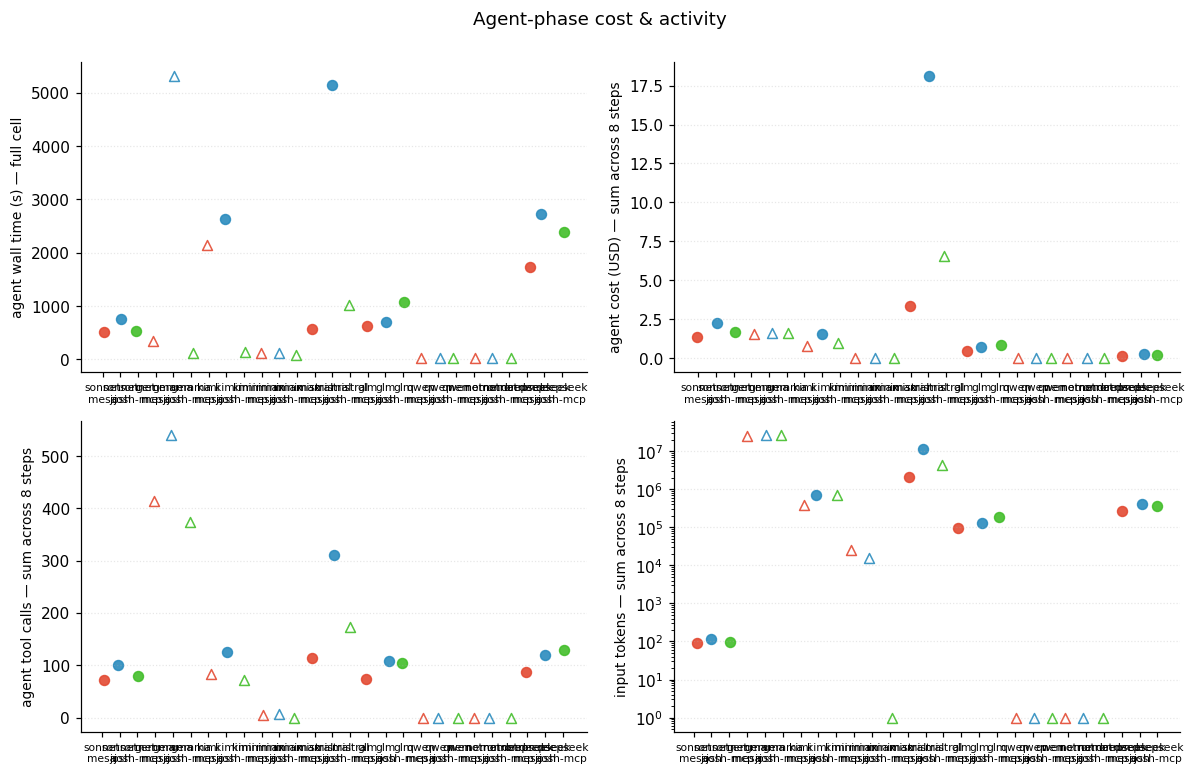

=== Per-(model, target) cost & timing summary ===
                   n  ran  sim_wall_med  agent_wall_min  cost_usd_mean  cost_usd_max  tool_calls_mean  in_tokens_k  cache_read_M
model    target                                                                                                                 
sonnet   mesa      1    1         56.68             8.6           1.37          1.37             71.0          0.1          1.64
         josh      1    1        254.89            12.8           2.26          2.26            101.0          0.1          3.28
         josh-mcp  1    1        308.38             8.7           1.67          1.67             79.0          0.1          1.98
gemma    mesa      1    0           NaN             5.8           1.58          1.58            415.0      25699.0          0.00
         josh      1    0           NaN            88.7           1.64          1.64            540.0      26505.3          0.00
         josh-mcp  1    0           NaN        

In [11]:
COST_FIELDS = [
    ('agent_wall_seconds',   'agent wall time (s) — full cell',         'linear'),
    ('agent_cost_usd',       'agent cost (USD) — sum across 8 steps',   'linear'),
    ('agent_tool_calls',     'agent tool calls — sum across 8 steps',   'linear'),
    ('agent_tokens_input',   'input tokens — sum across 8 steps',       'log'),
]


def panel_cost(df_in: pd.DataFrame, axes: np.ndarray) -> None:
    df_c = df_in.copy()
    df_c['xkey'] = df_c['model'] + '\n' + df_c['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=23)

    for ax, (field, ylabel, scale) in zip(axes.flat, COST_FIELDS):
        for g in groups:
            sub = df_c[df_c['xkey'] == g]
            if sub.empty:
                continue
            xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
            for x, val, ran, tgt in zip(xs, sub[field].astype(float),
                                         sub['did_run'], sub['target']):
                marker = 'o' if bool(ran) else '^'
                facecolor = TARGET_COLORS[tgt] if bool(ran) else 'white'
                # log scale needs a positive floor.
                y_plot = max(float(val), 1) if scale == 'log' else float(val)
                ax.scatter([x], [y_plot], marker=marker, c=[facecolor],
                           s=42, alpha=0.9,
                           edgecolor=TARGET_COLORS[tgt], linewidth=1.0)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(groups, fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_yscale(scale)
        ax.grid(axis='y', alpha=0.3, linestyle=':')


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panel_cost(df, axes)
fig.suptitle('Agent-phase cost & activity', y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'cost_walltime.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'cost_walltime.png', bbox_inches='tight')
plt.show()

cost_tbl = (df.groupby(['model', 'target'])
              .agg(n=('did_run', 'size'),
                   ran=('did_run', 'sum'),
                   sim_wall_med=('sim_wall_seconds', 'median'),
                   agent_wall_min=('agent_wall_seconds',
                                    lambda s: round(s.mean() / 60, 1)),
                   cost_usd_mean=('agent_cost_usd', 'mean'),
                   cost_usd_max=('agent_cost_usd', 'max'),
                   tool_calls_mean=('agent_tool_calls', 'mean'),
                   in_tokens_k=('agent_tokens_input',
                                 lambda s: round(s.mean() / 1000, 1)),
                   cache_read_M=('agent_tokens_cache_read',
                                  lambda s: round(s.mean() / 1_000_000, 2)))
              .reindex(index=pd.MultiIndex.from_product(
                          [MODEL_ORDER, TARGET_ORDER], names=['model', 'target']),
                       fill_value=0))
print('=== Per-(model, target) cost & timing summary ===')
print(cost_tbl.round(2).to_string())
print()
total_cost = df['agent_cost_usd'].fillna(0).sum()
total_agent_h = df['agent_wall_seconds'].fillna(0).sum() / 3600
total_sim_s = df['sim_wall_seconds'].fillna(0).sum()
total_tools = int(df['agent_tool_calls'].fillna(0).sum())
print(f'BATCH TOTAL: ${total_cost:.2f} | '
      f'{total_agent_h:.1f} agent-hours | '
      f'{total_sim_s:.0f} sim-seconds | '
      f'{total_tools} tool calls')


## Fuzzy-judge readout — Q1 / Q2 / Q3 per cell

The in-Pod LLM judge (`/opt/run-judge.sh` in the scorer container; see
[prompts/FUZZY_JUDGE.md](../prompts/FUZZY_JUDGE.md) for the contract)
answers three questions per cell against the agent's workspace,
transcript, and `scorer.json`:

- **Q1.** Did the agent actually use the named target framework as the
  primary modelling vehicle? `yes` / `partial` / `no`. Catches the
  `target_conformance = True` loophole where the agent imports the
  framework but does the real work in plain numpy.
- **Q2.** Where did the agent get stuck? Free text 2–4 sentences,
  surfacing failure modes the mechanical scorer can't describe.
- **Q3.** Does `./run.sh` carry preprocess + 100 replicates +
  2024..2123? `yes` / `partial` / `no`. **Load-bearing for the runtime
  panel above** — a cell answering `partial`/`no` isn't
  apples-to-apples on `sim_wall_seconds`, and is rendered with a
  hollow marker in that figure.

Cells from pre-judge batches show empty fuzzy columns; the section
renders empty rows for those cells without erroring.


In [12]:
import textwrap

Q_GLYPH = {'yes': '✓', 'no': '✗', 'partial': '~'}


def _wrap(text, width=92, indent='      '):
    if not isinstance(text, str) or not text.strip():
        return '(none)'
    return ('\n' + indent).join(textwrap.wrap(text.strip(), width=width)) or '(none)'


def _glyph(answer):
    return Q_GLYPH.get(answer, '?')


# Pivot of Q1 + Q3 distributions — quick scan of how many cells passed
# each judge gate.
def _distribution(df_in, col):
    p = (df_in.assign(present=1)
              .pivot_table(index=['model', 'target'],
                           columns=col,
                           values='present',
                           aggfunc='sum',
                           fill_value=0))
    for ans in ('yes', 'partial', 'no'):
        if ans not in p.columns:
            p[ans] = 0
    p = p[['yes', 'partial', 'no']]
    return p.reindex(
        index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                          names=['model', 'target']),
        fill_value=0)


fuzzy_present = df['fuzzy_q1_answer'].notna() & (df['fuzzy_q1_answer'] != '')
n_judged = int(fuzzy_present.sum())
print(f'cells with fuzzy data: {n_judged} / {len(df)}')

if n_judged == 0:
    print('(no scorer.fuzzy.json files present — re-run with the scorer image '
          'that includes run-judge.sh, or invoke '
          'orchestration/run_fuzzy_judge.sh against the pulled batch.)')
else:
    print()
    print('=== Q1 distribution — did the agent use the named framework? ===')
    print(_distribution(df[fuzzy_present], 'fuzzy_q1_answer'))
    print()
    print('=== Q3 distribution — does ./run.sh carry the full workload? ===')
    print(_distribution(df[fuzzy_present], 'fuzzy_q3_answer'))
    print()
    parse_errs = df[df['fuzzy_parse_error'].notna() & (df['fuzzy_parse_error'] != '')]
    if not parse_errs.empty:
        print(f'Parse errors on {len(parse_errs)} cell(s):')
        for _, row in parse_errs.iterrows():
            print(f"  - {row['run_id']}: {str(row['fuzzy_parse_error'])[:120]}")
        print()
    print('=== Per-cell judge text (sorted by model, target, Q3) ===')
    print()
    ordered = df[fuzzy_present].assign(
        _m=df['model'].map({m: i for i, m in enumerate(MODEL_ORDER)}),
        _t=df['target'].map({t: i for i, t in enumerate(TARGET_ORDER)}),
        _q3=df['fuzzy_q3_answer'].map({'yes': 0, 'partial': 1, 'no': 2}).fillna(3),
    ).sort_values(['_m', '_t', '_q3', 'run_id'])

    for _, row in ordered.iterrows():
        q1g = _glyph(row['fuzzy_q1_answer'])
        q3g = _glyph(row['fuzzy_q3_answer'])
        h100 = row['height_year100_mean']
        h100_s = f'{h100:.1f}' if pd.notna(h100) else '—'
        header = (
            f"[Q1 {q1g}] [Q3 {q3g}] {row['model']:<8s} {row['target']:<5s} "
            f"did_run={'Y' if row['did_run'] else 'N'}  "
            f"fit_ok={'Y' if row['regression_fit_ok'] else 'N'}  "
            f"h100={h100_s}m  "
            f"sim={row['sim_wall_seconds']:.0f}s"
        )
        print(header)
        print(f"   Q1: {_wrap(row.get('fuzzy_q1_justification'))}")
        print(f"   Q2: {_wrap(row.get('fuzzy_q2_observations'))}")
        print(f"   Q3: {_wrap(row.get('fuzzy_q3_justification'))}")
        print()


cells with fuzzy data: 16 / 27

=== Q1 distribution — did the agent use the named framework? ===
fuzzy_q1_answer    yes  partial  no
model    target                    
sonnet   mesa        1        0   0
         josh        1        0   0
         josh-mcp    1        0   0
gemma    mesa        0        0   0
         josh        0        0   0
         josh-mcp    0        0   0
kimi     mesa        1        0   0
         josh        1        0   0
         josh-mcp    0        0   0
minimax  mesa        0        0   1
         josh        0        0   0
         josh-mcp    0        0   1
mistral  mesa        1        0   0
         josh        1        0   0
         josh-mcp    1        0   0
glm      mesa        1        0   0
         josh        1        0   0
         josh-mcp    1        0   0
qwen     mesa        0        0   0
         josh        0        0   0
         josh-mcp    0        0   0
nemotron mesa        0        0   0
         josh        0        0   0
   

### Appendix: per-(model, target) summary table

Companion to the figures for the paper text — k/N pass rates and per-gate
counts.


In [13]:
tbl = (df.groupby(['model', 'target'])
         .agg(n=('did_run', 'size'),
              did_run=('did_run', 'sum'),
              conformed=('target_conformance', 'sum'),
              substantively_conformed=('substantive_conformance', 'sum'),
              fit_ok=('regression_fit_ok', 'sum'),
              height_in_range=('height_in_range', 'sum'))
         .reindex(index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                                    names=['model', 'target']),
                  fill_value=0))
tbl['did_run_rate'] = (tbl['did_run'] / tbl['n']).round(2)
tbl['conform_rate'] = (tbl['conformed'] / tbl['n']).round(2)
tbl['substantive_rate'] = (tbl['substantively_conformed'] / tbl['n']).round(2)
tbl['fit_ok_rate']  = (tbl['fit_ok']  / tbl['n']).round(2)
tbl


n  did_run  conformed  substantively_conformed  fit_ok  \
model    target                                                             
sonnet   mesa      1        1          1                        1       1   
         josh      1        1          1                        1       1   
         josh-mcp  1        1          1                        1       1   
gemma    mesa      1        0          0                        0       0   
         josh      1        0          0                        0       0   
         josh-mcp  1        0          0                        0       0   
kimi     mesa      1        0          1                        1       0   
         josh      1        1          1                        1       1   
         josh-mcp  1        0          0                        0       0   
minimax  mesa      1        0          0                        0       0   
         josh      1        0          0                        0       0   
         josh-mcp  1        0          0                        0       0   
mistral  mesa      1        1          1                        1       1   
         josh      1        1          1                        1       0   
         josh-mcp  1        0          0                        0       1   
glm      mesa      1        1          1                        1       1   
         josh      1        1          1                        1       1   
         josh-mcp  1        1          1                        1       1   
qwen     mesa      1        0          0                        0       0   
         josh      1        0          0                        0       0   
         josh-mcp  1        0          0                        0       0   
nemotron mesa      1        0          0                        0       0   
         josh      1        0          0                        0       0   
         josh-mcp  1        0          0                        0       0   
deepseek mesa      1        1          1                        1       1   
         josh      1        1          1                        1       1   
         josh-mcp  1        1          1                        1       1   

                   height_in_range  did_run_rate  conform_rate  \
model    target                                                  
sonnet   mesa                    1           1.0           1.0   
         josh                    1           1.0           1.0   
         josh-mcp                1           1.0           1.0   
gemma    mesa                    0           0.0           0.0   
         josh                    0           0.0           0.0   
         josh-mcp                0           0.0           0.0   
kimi     mesa                    0           0.0           1.0   
         josh                    1           1.0           1.0   
         josh-mcp                0           0.0           0.0   
minimax  mesa                    0           0.0           0.0   
         josh                    0           0.0           0.0   
         josh-mcp                0           0.0           0.0   
mistral  mesa                    1           1.0           1.0   
         josh                    1           1.0           1.0   
         josh-mcp                1           0.0           0.0   
glm      mesa                    1           1.0           1.0   
         josh                    1           1.0           1.0   
         josh-mcp                1           1.0           1.0   
qwen     mesa                    0           0.0           0.0   
         josh                    0           0.0           0.0   
         josh-mcp                0           0.0           0.0   
nemotron mesa                    0           0.0           0.0   
         josh                    0           0.0           0.0   
         josh-mcp                0           0.0           0.0   
deepseek mesa                    1           1.0           1.0   
   